In [92]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import contextily as cx
import matplotlib.pyplot as plt
import pointpats
import numpy as np
import esda
import tobler
import pyinterpolate

from matplotlib import patches
from libpysal import graph
from scipy import interpolate
from sklearn import neighbors

In [93]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
obce_polygony = gpd.read_file("geometrie/OBCE_SILC.shp").to_crs(5514)
obce_skolky = gpd.sjoin(skolky_body,obce_polygony)

In [94]:
skolky_body = obce_skolky[
    (obce_skolky["OBLAST_KOD"]==3) & (obce_skolky["TYP_KOD"] == 4) |
    (obce_skolky["OBLAST_KOD"]==2) & (obce_skolky["TYP_KOD"] == 4) |
    (obce_skolky["OBLAST_KOD"]==3) & (obce_skolky["TYP_KOD"] == 3) ]


In [95]:
skolky_body2 = skolky_body.loc[skolky_body["Zřizovate"] == 2]

In [96]:
skolky_body2["monthly_fe"] = skolky_body2["monthly_fe"].astype(float)

In [97]:
skolky_N_body = skolky_body2.loc[skolky_body2["monthly_fe"].isna()]
skolky_Z_body = skolky_body2.loc[skolky_body2["monthly_fe"].notna()]

<Axes: >

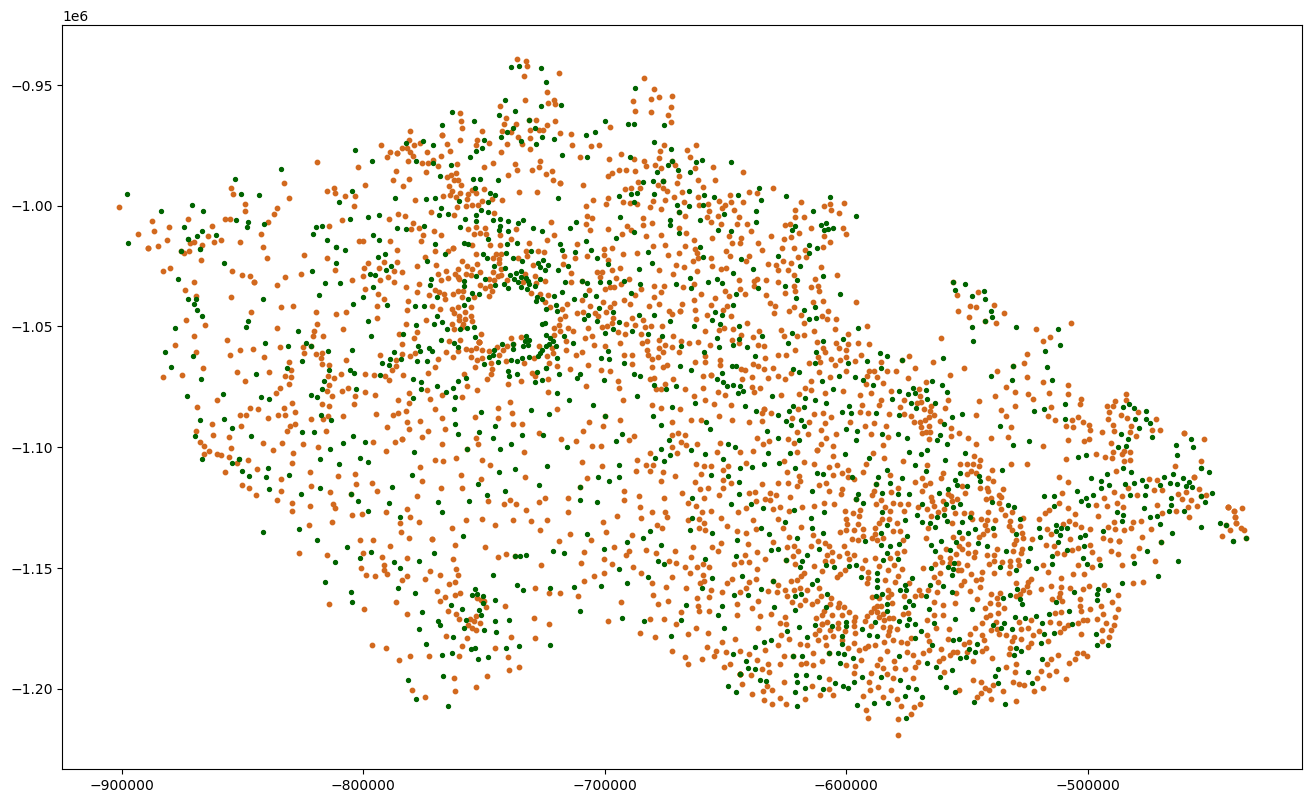

In [98]:
ax = skolky_N_body.plot(figsize=(16,10),markersize=10, color="chocolate")
skolky_Z_body.plot(markersize=8, color="darkgreen", ax=ax, )


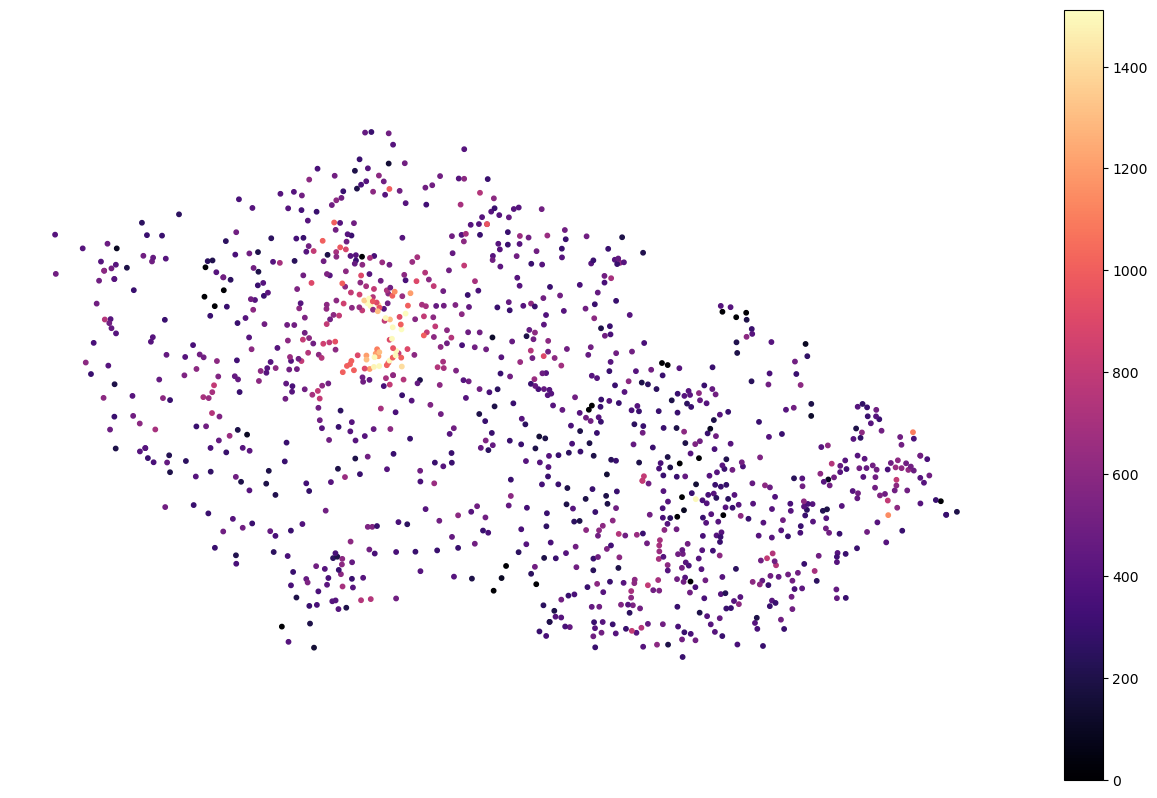

In [99]:
ax = skolky_Z_body.plot("monthly_fe", figsize=(16,10),markersize=10, cmap="magma", legend=True)
ax.set_axis_off()


In [100]:
k = [5,6,7,8,9, 10, 15,25, 50, 75, 100]
correlogram = esda.correlogram(
    geometry=skolky_Z_body,
    variable=skolky_Z_body["monthly_fe"],
    support=k,
    distance_type="knn",
)   

In [101]:
correlogram.I


5      0.587736
6      0.570564
7      0.568869
8      0.561275
9      0.555891
10     0.548517
15     0.531999
25     0.498510
50     0.449631
75     0.415385
100    0.389680
Name: I, dtype: float64

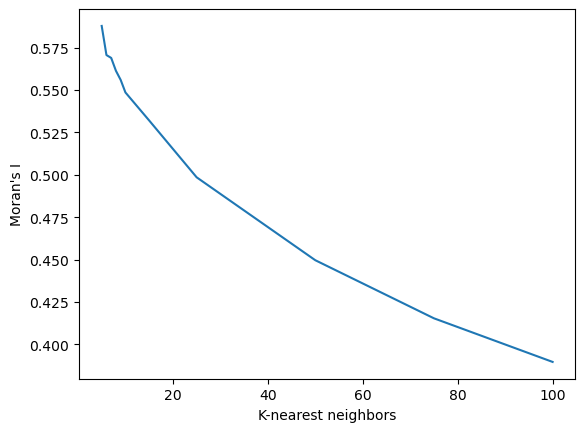

In [102]:
ax = correlogram.I.plot()
ax.set_xlabel("K-nearest neighbors")
_ = ax.set_ylabel("Moran's I")

In [103]:
knn10_kernel = graph.Graph.build_knn(skolky_Z_body, k=15,coplanar="jitter")
row_knn10_kernel = knn10_kernel.transform("r")


In [104]:
skolky_Z_body["fee_lag"] = row_knn10_kernel.lag(skolky_Z_body["monthly_fe"])


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [105]:
skolky_Z_body["fee_std"] = (
    skolky_Z_body["monthly_fe"] - skolky_Z_body["monthly_fe"].mean()
) / skolky_Z_body["monthly_fe"].std()

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [106]:
skolky_Z_body["fee_std_lag"] = row_knn10_kernel.lag(skolky_Z_body["fee_std"])


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [107]:
# Vypočítej a ulož hodnotu Moranovo I pro "monthly_fe" se zadanou maticí prostorových vah.
mi = esda.Moran(skolky_Z_body["monthly_fe"], row_knn10_kernel)

# Vypiš zadaný text a hodnotu Moranova I a jeho p-hodnotu.
print("Moranovo I =",mi.I)
print("P-hodnota =",mi.p_sim)

Moranovo I = 0.5325464098287772
P-hodnota = 0.001


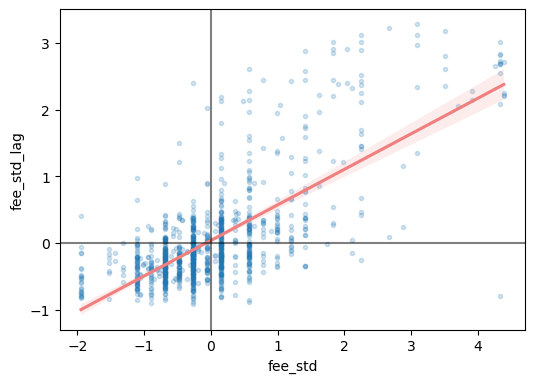

In [108]:
f, ax = plt.subplots(1, figsize=(6, 6))
sns.regplot(
    x="fee_std",
    y="fee_std_lag",
    data=skolky_Z_body,
    marker=".",
    scatter_kws={"alpha": 0.2},
    line_kws=dict(color="lightcoral")
)
ax.set_aspect('equal')
plt.axvline(0, c="black", alpha=0.5)
plt.axhline(0, c="black", alpha=0.5)


In [109]:
lisa = esda.Moran_Local(skolky_Z_body["monthly_fe"], row_knn10_kernel)


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

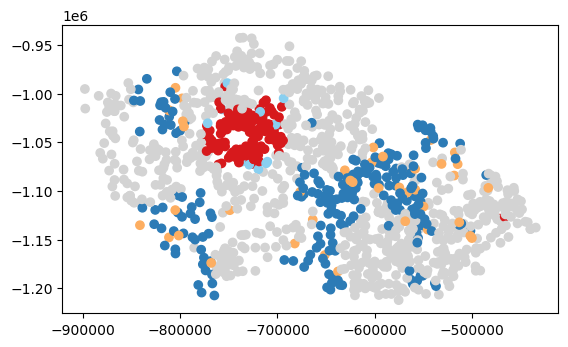

In [110]:
skolky_Z_body['cluster'] = lisa.get_cluster_labels(crit_value=0.05)
lisa.plot(
    skolky_Z_body,
    crit_value=0.05,
)

In [111]:
skolky_Z_coordinates = skolky_Z_body.get_coordinates()
skolky_N_coordinates = skolky_N_body.get_coordinates()



In [112]:
interpolation_distance = neighbors.KNeighborsRegressor(n_neighbors=10, weights="distance")
interpolation_distance.fit(skolky_Z_coordinates, skolky_Z_body.fee_lag)

,n_neighbors,10
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [113]:
interpolation_radius = neighbors.RadiusNeighborsRegressor(radius=15000, weights="distance")
interpolation_radius.fit(skolky_Z_coordinates, skolky_Z_body.fee_lag)

,radius,15000
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [114]:
skolky_N_body["knn_distance"] = interpolation_distance.predict(skolky_N_coordinates)
skolky_N_body["radius"] = interpolation_radius.predict(skolky_N_coordinates)

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/sklearn/neighbors/_regression.py:508: UserWarning: One or more samples have no neighbors within specified radius; predicting NaN.
  warnings.warn(empty_warning_msg)
/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

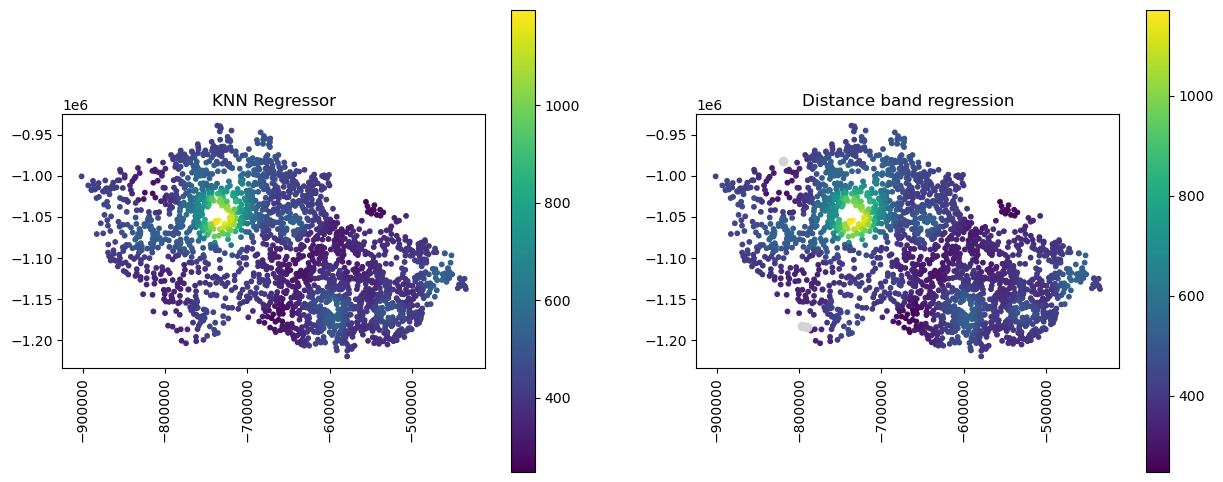

In [115]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(15, 6))
skolky_N_body.plot("knn_distance", ax=ax1, legend=True,markersize=10)
skolky_N_body.plot("radius", ax=ax2, legend=True, missing_kwds={"color": "lightgrey"},markersize=10)

# Nastav nadpisy a otoč popisky na ose x o 90 stupnů.
ax1.set_title("KNN Regressor")
ax2.set_title("Distance band regression")
ax1.tick_params(axis="x",rotation=90)
ax2.tick_params(axis="x",rotation=90);

In [116]:
exp_semivar = pyinterpolate.build_experimental_variogram(
    skolky_Z_body[['geometry', 'monthly_fe']],
    step_size=50,
    max_range=5000,
)

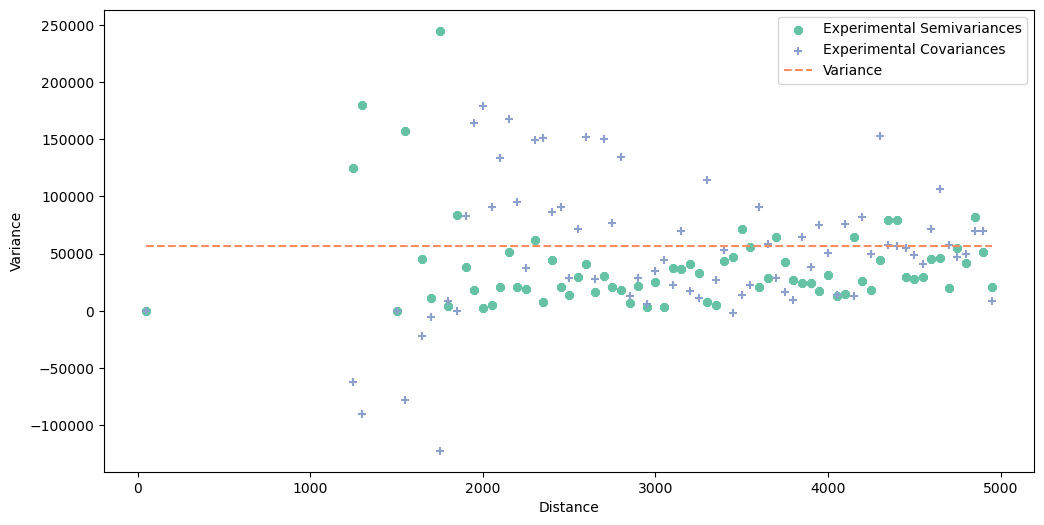

In [117]:
exp_semivar.plot()


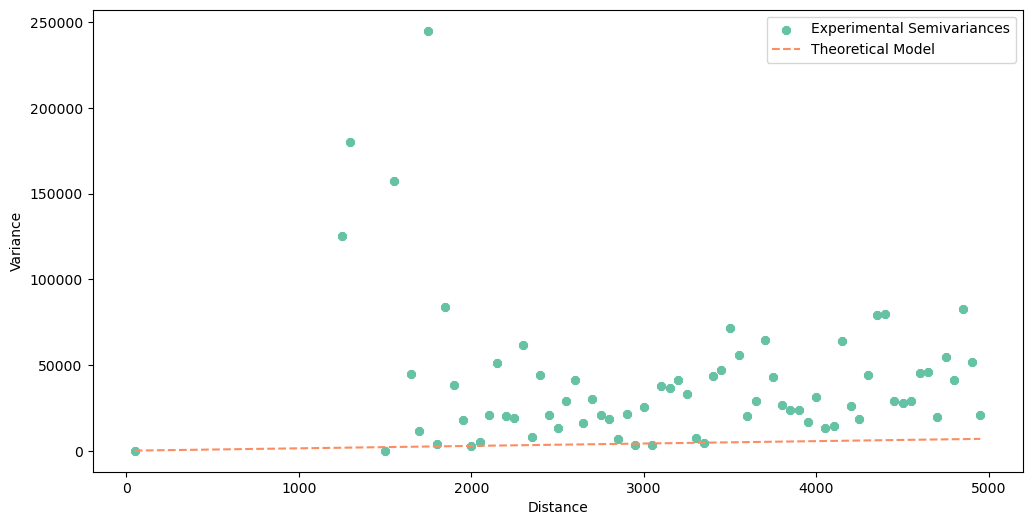

In [118]:
semivar = pyinterpolate.build_theoretical_variogram(
    experimental_variogram=exp_semivar,
)
semivar.plot()


In [119]:
skolky_Z = skolky_Z_body.drop_duplicates("geometry")


In [120]:
ordinary_kriging = pyinterpolate.interpolate_points(
    theoretical_model=semivar,
    known_locations=    skolky_Z[['geometry', 'monthly_fe']],
    unknown_locations=skolky_N_body.geometry,
    no_neighbors=10,
    progress_bar=False,
)

In [121]:
skolky_N_body["ordinary_kriging"] = ordinary_kriging[:, 0]


/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


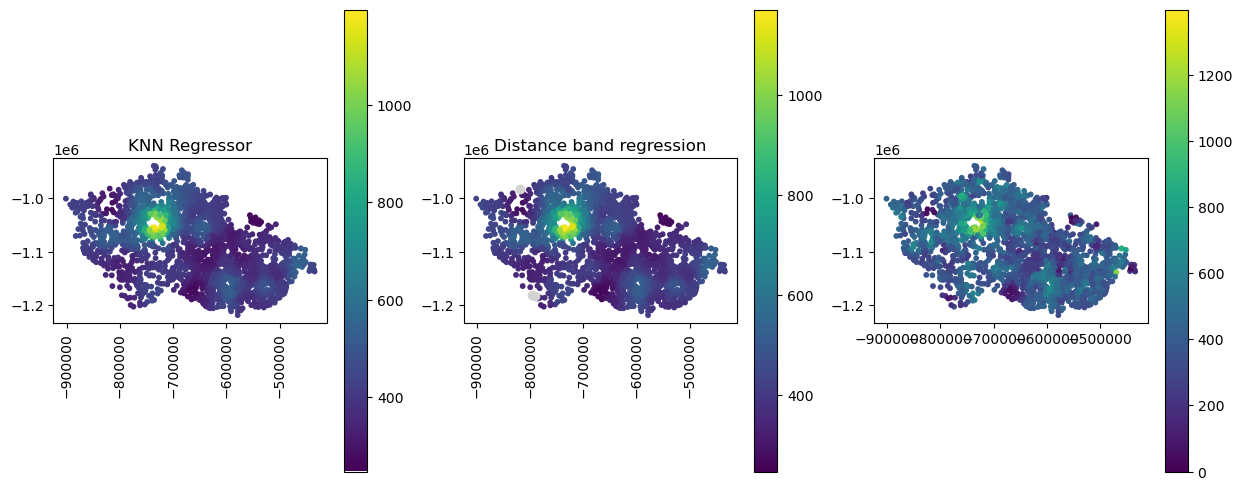

In [122]:
f, (ax1, ax2,ax3) = plt.subplots(1,3, figsize=(15, 6))
skolky_N_body.plot("knn_distance", ax=ax1, legend=True,markersize=10)
skolky_N_body.plot("radius", ax=ax2, legend=True, missing_kwds={"color": "lightgrey"},markersize=10)
skolky_N_body.plot("ordinary_kriging", ax=ax3, legend=True,markersize=10)

# Nastav nadpisy a otoč popisky na ose x o 90 stupnů.
ax1.set_title("KNN Regressor")
ax2.set_title("Distance band regression")
ax1.tick_params(axis="x",rotation=90)
ax2.tick_params(axis="x",rotation=90);

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

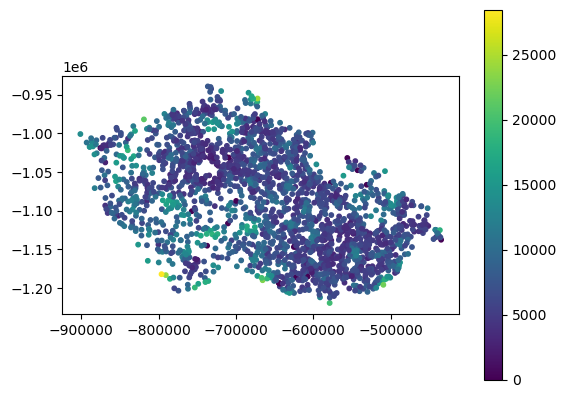

In [123]:
skolky_N_body["variance_error"] = ordinary_kriging[:, 1]
skolky_N_body.plot("variance_error", legend=True,markersize=10)

In [124]:
skolky_N_body["monthly_fe"] = skolky_N_body["ordinary_kriging"]

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [125]:
skolky_N_body = skolky_N_body.drop(columns=["knn_distance","radius","ordinary_kriging","variance_error"])

In [126]:
skolky_all = pd.concat([skolky_N_body, skolky_Z_body])

In [127]:
skolky_all = skolky_all.drop(columns=["fee_lag","fee_std","fee_std_lag","cluster"])


In [128]:
skolky_all.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
#skolky_all.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")

In [88]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/ORP.geojson")

In [89]:
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

<Axes: >

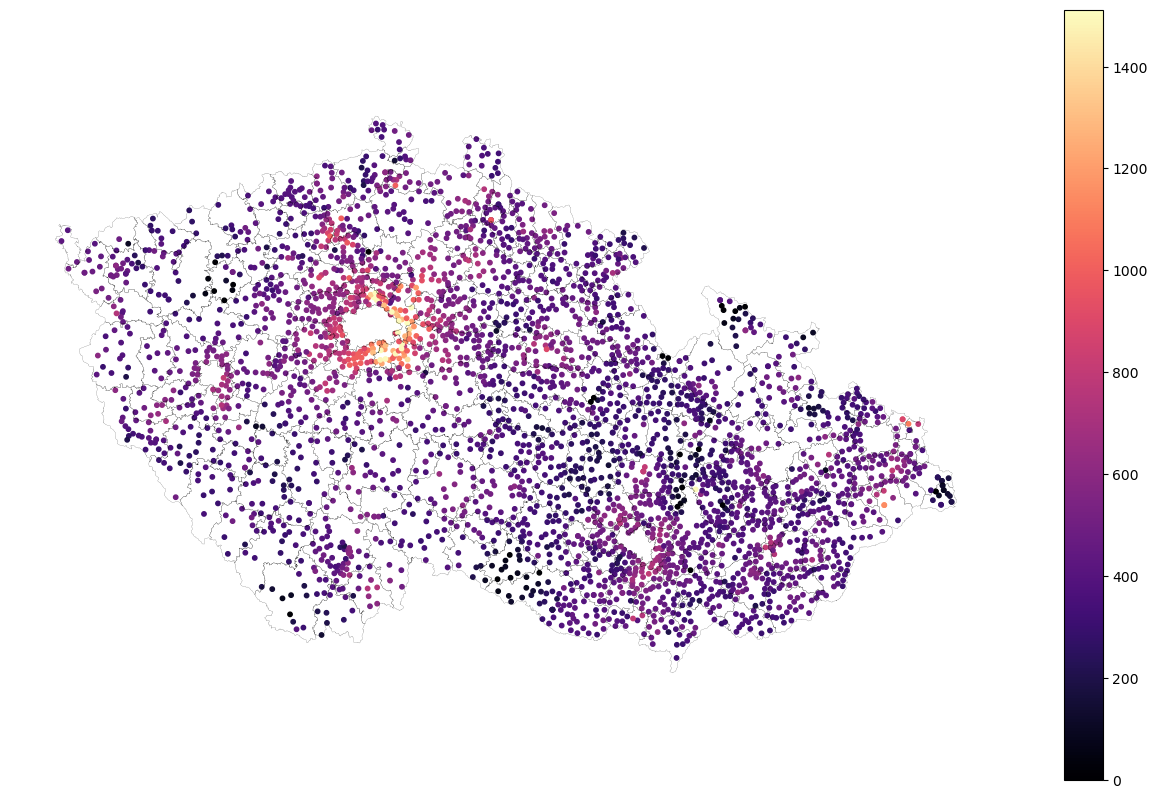

In [90]:
ax = skolky_all.plot("monthly_fe", figsize=(16,10),markersize=10, cmap="magma", legend=True)
ax.set_axis_off()
orp_polygony.plot(ax=ax,     facecolor="none",    edgecolor="black", linewidth=0.1)

In [91]:
skolky_all.groupby('Název_ORP').size()

Název_ORP
Aš                   3
Benešov             21
Beroun              28
Blansko             28
Blatná               4
                    ..
Žamberk             18
Žatec                7
Železný Brod         7
Židlochovice        19
Žďár nad Sázavou    23
Length: 204, dtype: int64

In [44]:
orp_counts_total = skolky_all.groupby("Název_ORP").size()
orp_counts = skolky_all.groupby('Název_ORP').size()


In [45]:
# merge the two dataframes on 'Název ORP'
table = pd.DataFrame({"total_count": orp_counts_total, "count": orp_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = skolky_all.groupby('Název_ORP')['monthly_fe'].mean()
table['median_fee'] = skolky_all.groupby('Název_ORP')['monthly_fe'].median()

table['std_fee'] = skolky_all.groupby('Název_ORP')['monthly_fe'].std()



table.sort_values('average_fee', ascending=False).head(20)

,total_count,count,percentage,average_fee,median_fee,std_fee
Název_ORP,,,,,,
Říčany,41,41,100.0,1149.763064,1196.421228,303.954461
Brandýs nad Labem-Stará Boleslav,52,52,100.0,1028.294342,1005.483034,306.550563
Český Brod,14,14,100.0,858.410702,825.308775,180.700942
Černošice,68,68,100.0,826.354431,800.000000,160.241809
Lysá nad Labem,13,13,100.0,750.807933,747.305775,84.860444
Neratovice,10,10,100.0,725.866526,728.099755,60.231442
Kralupy nad Vltavou,16,16,100.0,719.797232,708.288676,77.855480
Frýdlant nad Ostravicí,10,10,100.0,689.256412,607.110601,276.000338
Jablonec nad Nisou,25,25,100.0,684.812396,700.000000,44.333677


In [46]:
orp = orp_polygony.merge(table, left_on ="naz_orp_p", right_index=True)

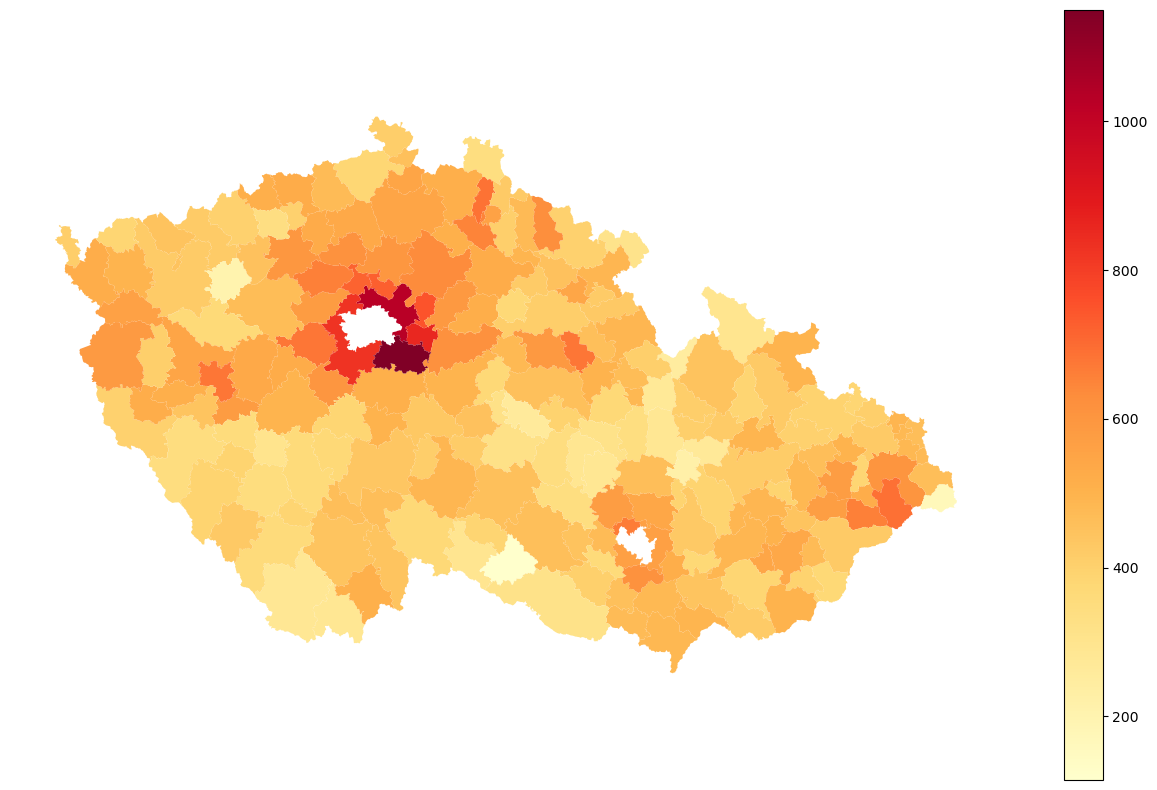

In [47]:
orp.plot("average_fee", figsize=(16,10),legend=True,cmap="YlOrRd").set_axis_off()

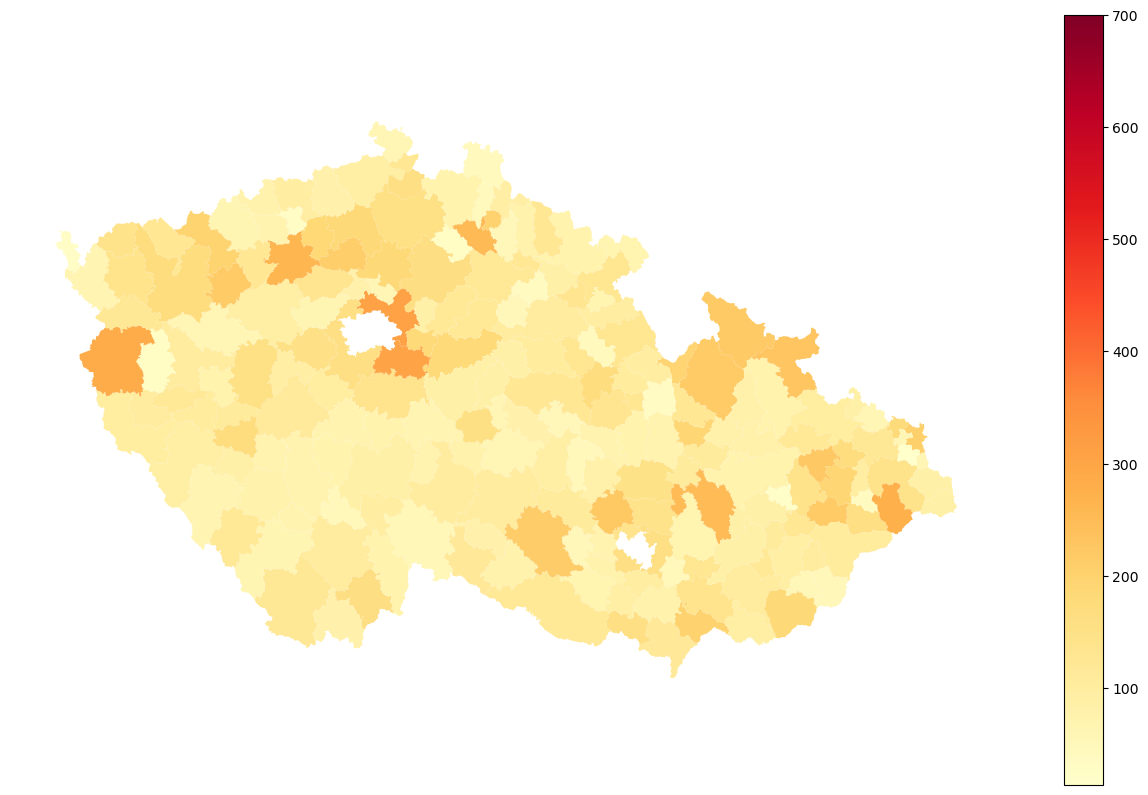

In [48]:
orp.plot("std_fee",figsize=(16,10), vmax=700,legend=True,cmap="YlOrRd", k=6).set_axis_off()